# EEE205 Artificial Intelligence I
## Part 14 - Neural Networks
## Tutorial solutions
### Barry Dillon

# Part 1

Provide definitions for each of the below concepts from the lecture. Again, try to do this without checking your notes, then improve the answers after using your notes.

- weights and biases
- perceptron
- neural network
- forward pass
- activation functions
- ReLU
- backpropagation
- training loop
- early stopping

# Part 2

In [1]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

1. The code below loads the Iris data.  Check it's shape and modify it to only pick out the petal features.

In [2]:
iris = load_iris()
X = iris.data[:, 2:4]  # features
y = iris.target        # labels: 0, 1, 2

feature_names = iris.feature_names[2:4]

2. The code below creates a version of the dataset with only two classes.  Comment the code.

In [3]:
mask_2class = y < 2             # keep class 0 and 1
X_2 = X[mask_2class]
y_2 = y[mask_2class]

3. Make a train/test split for this dataset.  Call the variables X2_train, X2_test, y2_train, y2_test.

In [4]:
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X_2, y_2, test_size=0.3, random_state=42, stratify=y_2
)

4. Below we define a Neural Network classifier in scikit-learn.  Comment the code to explain what each hyper-parameter means.

In [5]:
mlp_2 = MLPClassifier(
    hidden_layer_sizes=(10,),
    activation="relu",
    solver="adam",
    max_iter=1000,
    random_state=55
)

5. Complete the code below to fit the parameters of the Neural Network.

In [6]:
mlp_2.fit(X2_train, y2_train)

C:\Users\Mariam\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(hidden_layer_sizes=(10,), max_iter=1000, random_state=55)

We can compute the accuracy using the `.score` method in the classifier.

In [7]:
y2_pred = mlp_2.predict(X2_test)
print("2-class train accuracy:", mlp_2.score(X2_train, y2_train))
print("2-class test accuracy:", mlp_2.score(X2_test, y2_test))
print()

2-class train accuracy: 1.0
2-class test accuracy: 1.0



6. Do the same analysis as above, but using the full 3 classes.  Call the folds in the split X3_train, etc.

In [8]:
X3_train, X3_test, y3_train, y3_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

mlp_3 = MLPClassifier(
    hidden_layer_sizes=(20,),  # slightly bigger for 3 classes
    activation="relu",
    solver="adam",
    max_iter=1000,
    random_state=42
)
mlp_3.fit(X3_train, y3_train)

C:\Users\Mariam\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(hidden_layer_sizes=(20,), max_iter=1000, random_state=42)

In [9]:
print("3-class train accuracy:", mlp_3.score(X3_train, y3_train))
print("3-class test accuracy:", mlp_3.score(X3_test, y3_test))

3-class train accuracy: 0.9714285714285714
3-class test accuracy: 0.9111111111111111


7. Compare the accuracies, why are they different?

8. The code below plots the decision boundary of the neural network in the 2D feature space.  Remind yourself of how this worked in logistic regression, it's the exact same here.  Comment the code below.

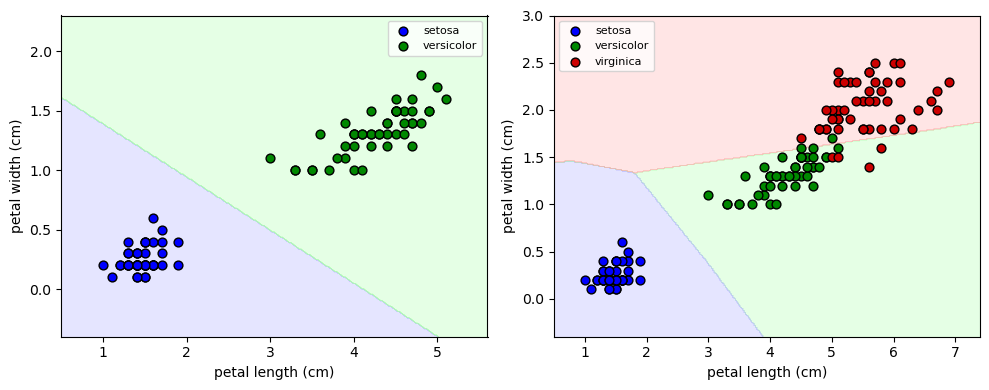

In [10]:
# -------------------------------------------------
# Helper: decision boundary plotting
# -------------------------------------------------
def plot_decision_boundary(ax, model, X, y, title, target_names=None):
    # Set up mesh over feature space
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid).reshape(xx.shape)

    # Colour maps
    n_classes = len(np.unique(y))
    cmap_light = ListedColormap(["#AAAAFF", "#AAFFAA", "#FFAAAA"][:n_classes])
    cmap_bold = ["#0000FF", "#008800", "#CC0000"]

    # Decision regions
    ax.contourf(xx, yy, Z, alpha=0.3, cmap=cmap_light)

    # Scatter training data
    for i, class_label in enumerate(np.unique(y)):
        label = target_names[i] if target_names is not None else f"class {class_label}"
        ax.scatter(
            X[y == class_label, 0],
            X[y == class_label, 1],
            edgecolor="k",
            s=40,
            label=label,
            c=cmap_bold[i]
        )

    ax.set_xlabel(feature_names[0])
    ax.set_ylabel(feature_names[1])
    ax.set_title(title)
    ax.legend(loc="best", fontsize=8)

# -------------------------------------------------
# Plot both decision boundaries
# -------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

plot_decision_boundary(
    axes[0],
    mlp_2,
    X_2,
    y_2,
    "",
    target_names=iris.target_names[:2],
)

plot_decision_boundary(
    axes[1],
    mlp_3,
    X,
    y,
    "",
    target_names=iris.target_names,
)
plt.savefig('iris-nn-3.png')
plt.tight_layout()
plt.show()
